## Analyzing the Similarity Globality Curves for layer_exp
This notebook measures how similarity metrics correlate with the absolute layer gap, split into same-seed pairs, different-seed pairs, and all pairs. Figures are saved into the active results directory.

In [12]:
import os
import pathlib
import sys

import numpy as np
import pandas as pd
from icecream import ic
from scipy.stats import kendalltau, spearmanr

sys.path.append(os.path.abspath("../"))
from utils import plot_rank_corrs

sys.path.append(os.path.abspath("../../"))
from paths import resources_path

In [ ]:
def get_latest_results_dir(results_root):
    candidates = [path for path in results_root.iterdir() if path.is_dir() and path.name != 'fast']
    if not candidates:
        raise ValueError(f'No run directories found under {results_root}')
    return max(candidates, key=lambda path: path.stat().st_mtime)

results_root = resources_path / pathlib.Path('results/layer_exp')
results_path = get_latest_results_dir(results_root)
full_df_path = results_path / 'full_df_self_computed.csv'
figures_path = results_path / 'figures'
figures_path.mkdir(parents=True, exist_ok=True)

print(f'Using results path: {results_path}')
print(f'Figures will be saved to: {figures_path}')

Using results path: /Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/layer_exp/20260601_120243
Figures will be saved to: /Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/layer_exp/20260601_120243/figures


In [14]:
full_df = pd.read_csv(full_df_path)
print(full_df.shape)
print(list(full_df.columns))

(78, 28)
['Unnamed: 0', 'dataset1', 'architecture1', 'seed1', 'step1', 'layer1', 'dataset2', 'architecture2', 'seed2', 'step2', 'layer2', 'PWCCA', 'mean_sq_cca_corr', 'mean_cca_corr', 'CKA', 'Procrustes', 'mutual_knn', 'mutual_knn_auc', 'cka_rbf', 'cka_rbf_auc', 'cknna', 'cknna_auc', 'softmax_rwka', 'softmax_rwka_auc', 'rbf_rwka', 'rbf_rwka_auc', 'QNLI_diff', 'SST-2_diff']


In [15]:
DEFAULT_METRICS = [
    'softmax_rwka', 'softmax_rwka_auc',
    'PWCCA', 'mean_cca_corr', 'mean_sq_cca_corr',
    'CSA', 'CKA', 'Procrustes',
    'cka_rbf', 'cka_rbf_auc',
    'mutual_knn', 'mutual_knn_auc',
    'cknna', 'cknna_auc',
]
METRICS = [metric for metric in DEFAULT_METRICS if metric in full_df.columns]
print(METRICS)

def metric_vs_layer_gap_corr(df, metrics, seed_mode='all'):
    if seed_mode == 'same':
        sub_df = df[df['seed1'] == df['seed2']].copy()
    elif seed_mode == 'different':
        sub_df = df[df['seed1'] != df['seed2']].copy()
    elif seed_mode == 'all':
        sub_df = df.copy()
    else:
        raise ValueError(f'Unknown seed_mode: {seed_mode}')

    sub_df = sub_df.copy()
    sub_df['abs_layer_diff'] = (sub_df['layer1'] - sub_df['layer2']).abs()

    gap_rho = {metric: [] for metric in metrics}
    gap_rho_p = {metric: [] for metric in metrics}
    gap_tau = {metric: [] for metric in metrics}
    gap_tau_p = {metric: [] for metric in metrics}

    for metric in metrics:
        if metric not in sub_df.columns:
            print(f'Metric {metric} not found in dataframe columns. Skipping.')
            continue

        x = sub_df[metric]
        y = sub_df['abs_layer_diff']
        if len(x) < 2 or x.nunique() < 2 or y.nunique() < 2:
            continue

        rho = spearmanr(x, y)
        tau = kendalltau(x, y)

        if np.isnan(rho.correlation) or np.isnan(tau.correlation):
            continue

        rho_corr = float(rho.correlation)
        tau_corr = float(tau.correlation)
        rho_os_p = (rho.pvalue / 2) if rho_corr > 0 else (1 - rho.pvalue / 2)
        tau_os_p = (tau.pvalue / 2) if tau_corr > 0 else (1 - tau.pvalue / 2)

        gap_rho[metric].append(rho_corr)
        gap_rho_p[metric].append(float(rho_os_p))
        gap_tau[metric].append(tau_corr)
        gap_tau_p[metric].append(float(tau_os_p))

    rows = []
    for metric in metrics:
        if len(gap_rho[metric]) == 0:
            continue
        rows.append({
            'metric': metric,
            'spearman_rho': round(float(np.mean(gap_rho[metric])), 3),
            'spearman_p': format(float(np.mean(gap_rho_p[metric])), '.1e'),
            'kendall_tau': round(float(np.mean(gap_tau[metric])), 3),
            'kendall_p': format(float(np.mean(gap_tau_p[metric])), '.1e'),
        })

    if len(rows) == 0:
        summary_df = pd.DataFrame(columns=['metric', 'spearman_rho', 'spearman_p', 'kendall_tau', 'kendall_p'])
    else:
        summary_df = pd.DataFrame(rows).sort_values('spearman_rho', ascending=False)

    metrics_present = [metric for metric in metrics if len(gap_rho[metric]) > 0]
    return summary_df, gap_rho, gap_rho_p, gap_tau, gap_tau_p, metrics_present

['softmax_rwka', 'softmax_rwka_auc', 'PWCCA', 'mean_cca_corr', 'mean_sq_cca_corr', 'CKA', 'Procrustes', 'cka_rbf', 'cka_rbf_auc', 'mutual_knn', 'mutual_knn_auc', 'cknna', 'cknna_auc']


In [16]:
for seed_mode in ['same', 'different', 'all']:
    summary_df, gap_rho, gap_rho_p, gap_tau, gap_tau_p, metrics_present = metric_vs_layer_gap_corr(
        full_df, METRICS, seed_mode=seed_mode
    )

    print(f'\nCorrelation with |layer1-layer2| (seed_mode={seed_mode}):')
    if len(summary_df) == 0:
        print('No valid correlations found.')
        continue

    print(summary_df.to_string(index=False))

    save_path = figures_path / f'layer_gap_corrs_{seed_mode}.png'
    plot_rank_corrs(
        gap_rho,
        gap_rho_p,
        gap_tau,
        gap_tau_p,
        metrics_present,
        title=f'layer_exp: metric vs |layer1-layer2| (seed_mode={seed_mode})',
        save_path=save_path,
    )
    summary_df.to_csv(figures_path / f'layer_gap_corrs_{seed_mode}.csv', index=False)
    print(f'Saved figure to {save_path}')


Correlation with |layer1-layer2| (seed_mode=same):
          metric  spearman_rho spearman_p  kendall_tau kendall_p
             CKA         0.981    9.2e-22        0.924   3.8e-10
      mutual_knn         0.981    9.2e-22        0.924   3.8e-10
  mutual_knn_auc         0.981    9.2e-22        0.924   3.8e-10
      Procrustes         0.950    6.3e-16        0.854   1.3e-09
           PWCCA         0.949    6.8e-16        0.851   1.4e-09
         cka_rbf         0.949    6.8e-16        0.851   1.4e-09
     cka_rbf_auc         0.949    6.8e-16        0.851   1.4e-09
           cknna         0.949    6.8e-16        0.851   1.4e-09
       cknna_auc         0.949    6.8e-16        0.851   1.4e-09
    softmax_rwka         0.937    1.2e-14        0.824   4.2e-09
softmax_rwka_auc         0.830    7.2e-09        0.683   8.9e-07
   mean_cca_corr        -0.949    1.0e+00       -0.851   1.0e+00
mean_sq_cca_corr        -0.949    1.0e+00       -0.851   1.0e+00
Saved figure to /Users/barweiss/Code/g

### Sweep curves by layer comparison
Plot similarity as a function of the sweep parameter between a reference layer and all other layers, split by same-seed vs different-seed pairs.

In [27]:
import json
import matplotlib.pyplot as plt


def list_sweep_metrics(sweeps_dir):
    metrics = set()
    for path in sweeps_dir.glob("*_auc__*.json"):
        name = path.name
        if "_auc__" in name:
            metrics.add(name.split("_auc__", 1)[0])
    return sorted(metrics)


def load_sweep_entries(metric_name, sweeps_dir):
    entries = []
    pattern = f"{metric_name}_auc__*.json"
    for sweep_file in sorted(sweeps_dir.glob(pattern)):
        with open(sweep_file, "r") as f:
            payload = json.load(f)
        metadata = payload.get("metadata", {})
        entries.append(
            {
                "metadata": metadata,
                "param_name": payload.get("param_name"),
                "param_values": np.asarray(payload.get("param_values", []), dtype=float),
                "scores": np.asarray(payload.get("scores", []), dtype=float),
            }
        )
    return entries


def _align_scores(param_values, scores, target_param_values):
    if len(param_values) == 0 or len(scores) == 0:
        return None
    order = np.argsort(param_values)
    param_values = param_values[order]
    scores = scores[order]
    return np.interp(target_param_values, param_values, scores)


def is_logscale_sweep(param_values, ratio_tol=0.05):
    if len(param_values) < 3:
        return False
    ratios = param_values[1:] / param_values[:-1]
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    return ratio_mean > 1.01 and (ratio_std / ratio_mean) < ratio_tol


def aggregate_layer_sweeps(entries, ref_layer, seed_mode="same", layers_to_plot=None):
    grouped = {}
    param_name = None
    for entry in entries:
        meta = entry["metadata"]
        seed1 = meta.get("seed1")
        seed2 = meta.get("seed2")
        layer1 = meta.get("layer1")
        layer2 = meta.get("layer2")

        if layer1 is None or layer2 is None:
            continue

        if seed_mode == "same" and seed1 != seed2:
            continue
        if seed_mode == "different" and seed1 == seed2:
            continue

        if layer1 == ref_layer:
            other_layer = layer2
        elif layer2 == ref_layer:
            other_layer = layer1
        else:
            continue

        if layers_to_plot is not None and other_layer not in layers_to_plot:
            continue

        if param_name is None:
            param_name = entry["param_name"]

        grouped.setdefault(other_layer, []).append(entry)

    if not grouped:
        return None, None, None

    # choose a reference param grid per layer
    aggregated = {}
    for other_layer, layer_entries in grouped.items():
        # pick the longest param vector as the target grid
        target_entry = max(layer_entries, key=lambda e: len(e["param_values"]))
        target_params = target_entry["param_values"]
        aligned_scores = []
        for entry in layer_entries:
            aligned = _align_scores(entry["param_values"], entry["scores"], target_params)
            if aligned is not None:
                aligned_scores.append(aligned)
        if not aligned_scores:
            continue
        scores_stack = np.vstack(aligned_scores)
        aggregated[other_layer] = {
            "param_values": target_params,
            "mean_scores": scores_stack.mean(axis=0),
            "std_scores": scores_stack.std(axis=0),
        }

    return aggregated, param_name, grouped


def plot_layer_sweep_curves(aggregated, metric_name, seed_mode, ref_layer, param_name, save_path):
    if not aggregated:
        print(f"No aggregated data for {metric_name} ({seed_mode}).")
        return None

    layers_sorted = sorted(aggregated.keys())
    cmap = plt.cm.get_cmap("viridis", max(len(layers_sorted), 1))

    fig, ax = plt.subplots(figsize=(12, 6))
    use_logscale = False
    for idx, other_layer in enumerate(layers_sorted):
        entry = aggregated[other_layer]
        color = cmap(idx)
        ax.plot(
            entry["param_values"],
            entry["mean_scores"],
            label=f"layer {other_layer}",
            color=color,
            linewidth=2.2,
        )
        ax.fill_between(
            entry["param_values"],
            entry["mean_scores"] - entry["std_scores"],
            entry["mean_scores"] + entry["std_scores"],
            color=color,
            alpha=0.18,
        )
        if not use_logscale:
            use_logscale = is_logscale_sweep(entry["param_values"])

    if use_logscale:
        ax.set_xscale("log")

    ax.set_title(
        f"{metric_name} sweep vs layer (ref_layer={ref_layer}, seed_mode={seed_mode})",
        fontsize=12,
    )
    ax.set_xlabel(param_name or "sweep parameter")
    ax.set_ylabel("Similarity score")
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9, framealpha=0.95)
    plt.tight_layout()

    fig.savefig(save_path, dpi=200)
    print(f"Saved figure to {save_path}")
    return fig

Sweep metrics found: ['cka_rbf', 'cknna', 'mutual_knn', 'rbf_rwka', 'softmax_rwka']


/var/folders/c0/vr2pr2z11nz67pj8r1w3l4sr0000gn/T/ipykernel_33348/1216751002.py:115: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("viridis", max(len(layers_sorted), 1))


Saved figure to /Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/layer_exp/20260601_120243/figures/layer_sweep_softmax_rwka_ref0_same.png
Saved figure to /Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/layer_exp/20260601_120243/figures/layer_sweep_softmax_rwka_ref0_different.png
Saved figure to /Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/layer_exp/20260601_120243/figures/layer_sweep_cka_rbf_ref0_same.png
Saved figure to /Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/layer_exp/20260601_120243/figures/layer_sweep_cka_rbf_ref0_different.png
Saved figure to /Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/layer_exp/20260601_120243/figures/layer_sweep_mutual_knn_ref0_same.png
Saved figure to /Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/layer_exp/20260601_120243/figures/layer_sweep_mutual_knn_ref0_different.png
Saved figure to /Users/barweiss/Code/grounded-repsim/sim_metric_resou

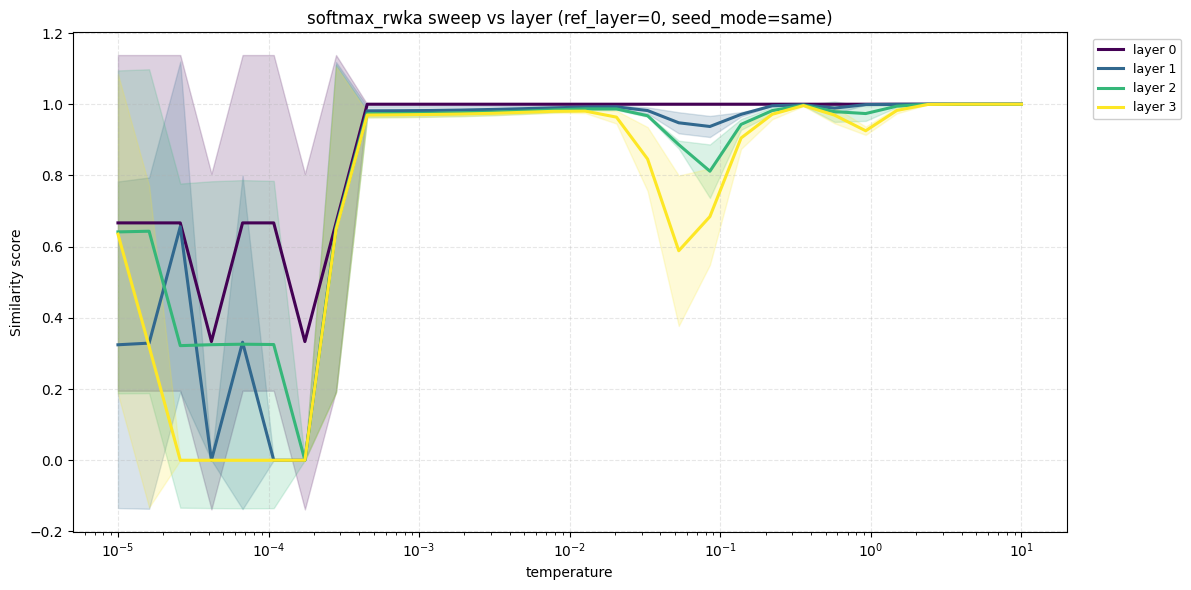

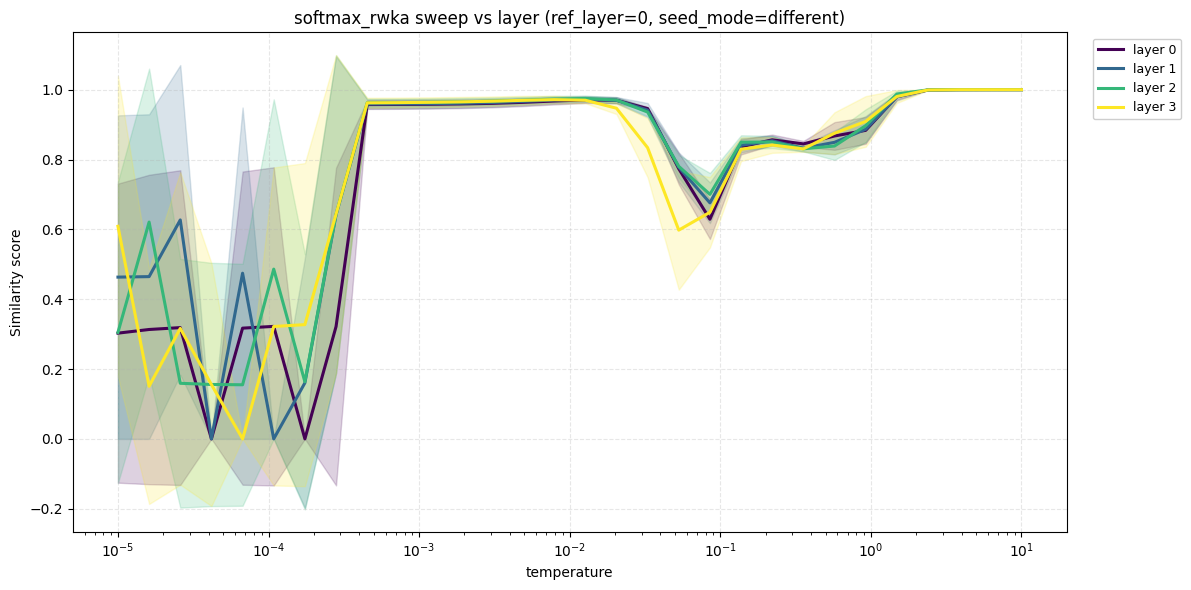

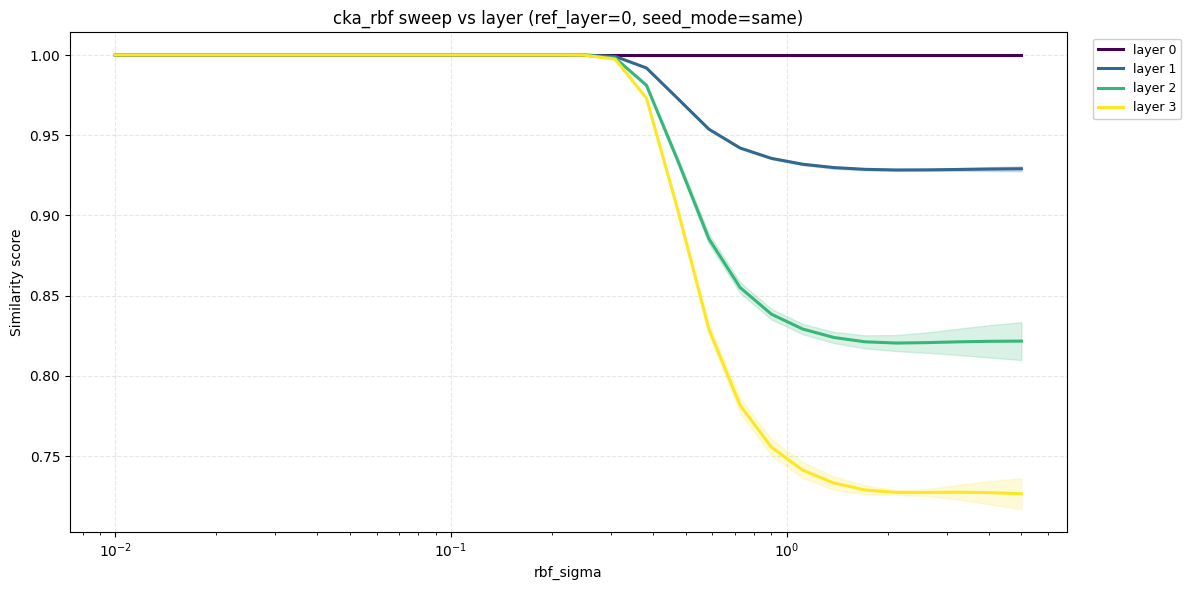

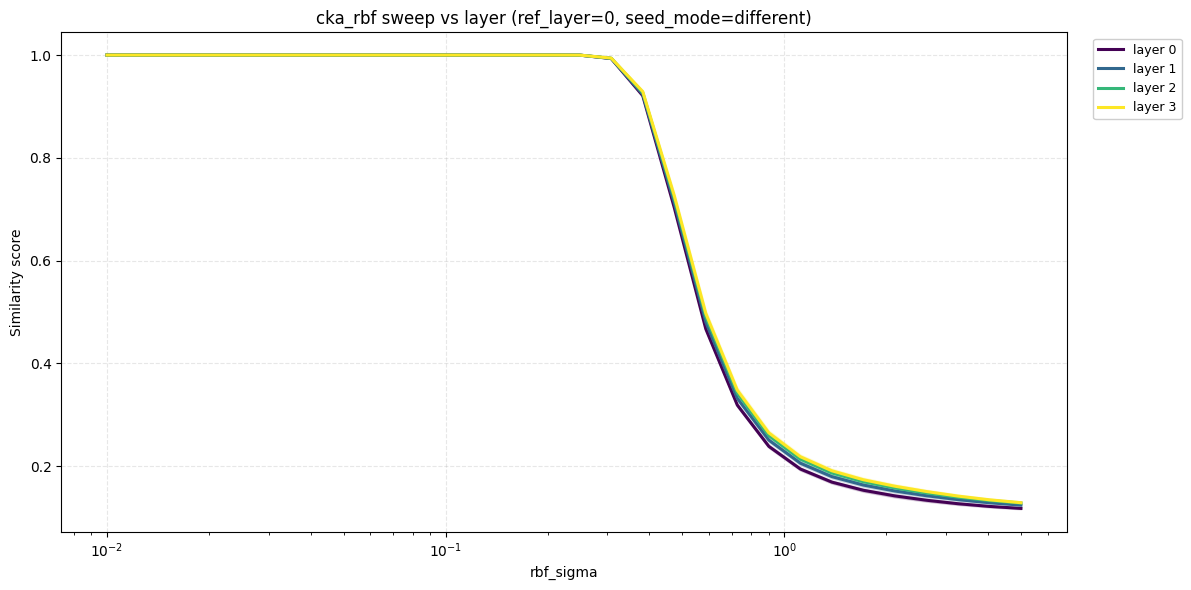

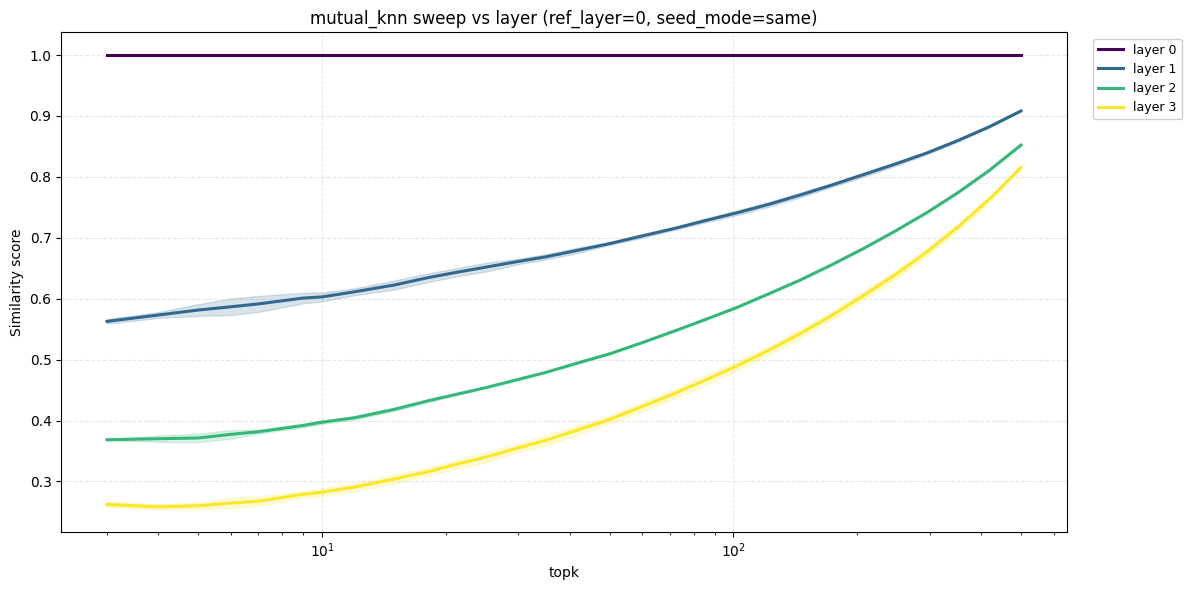

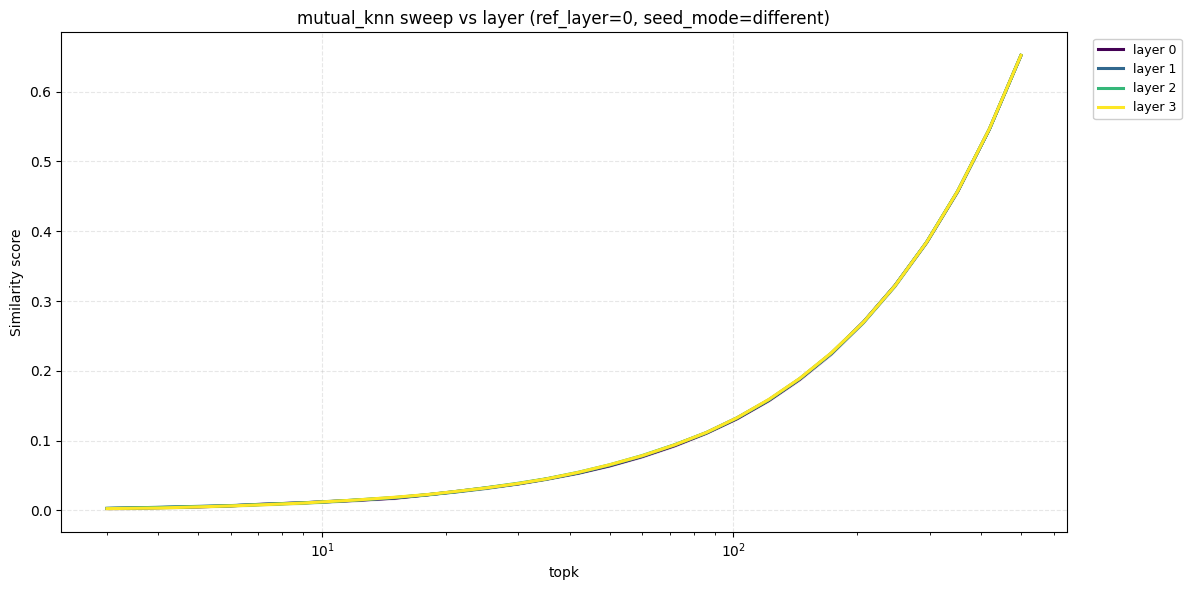

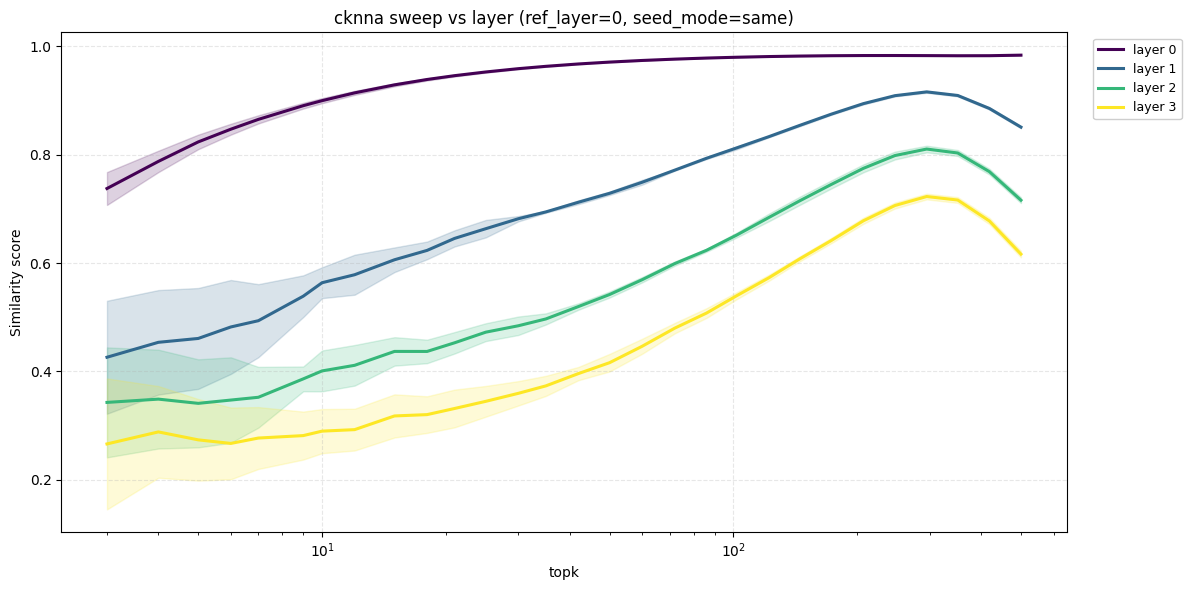

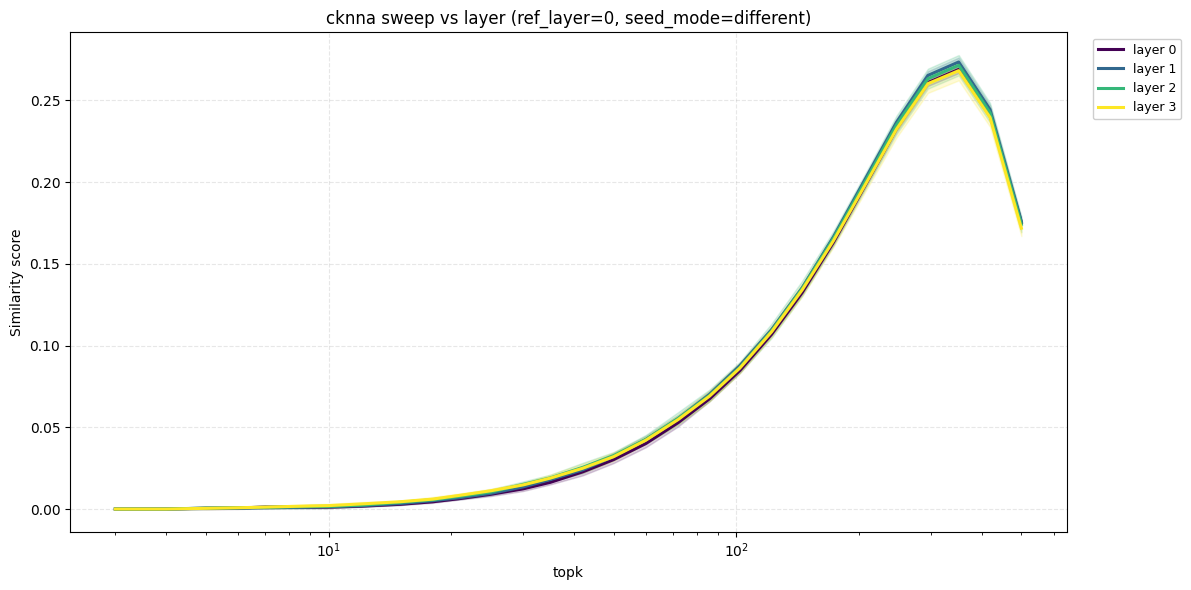

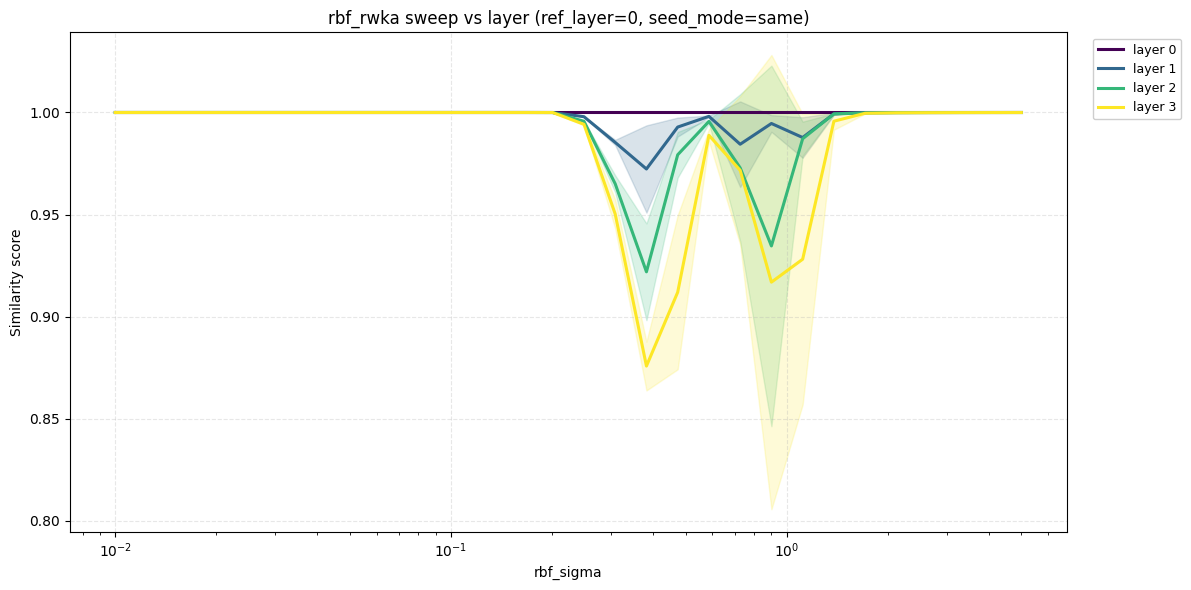

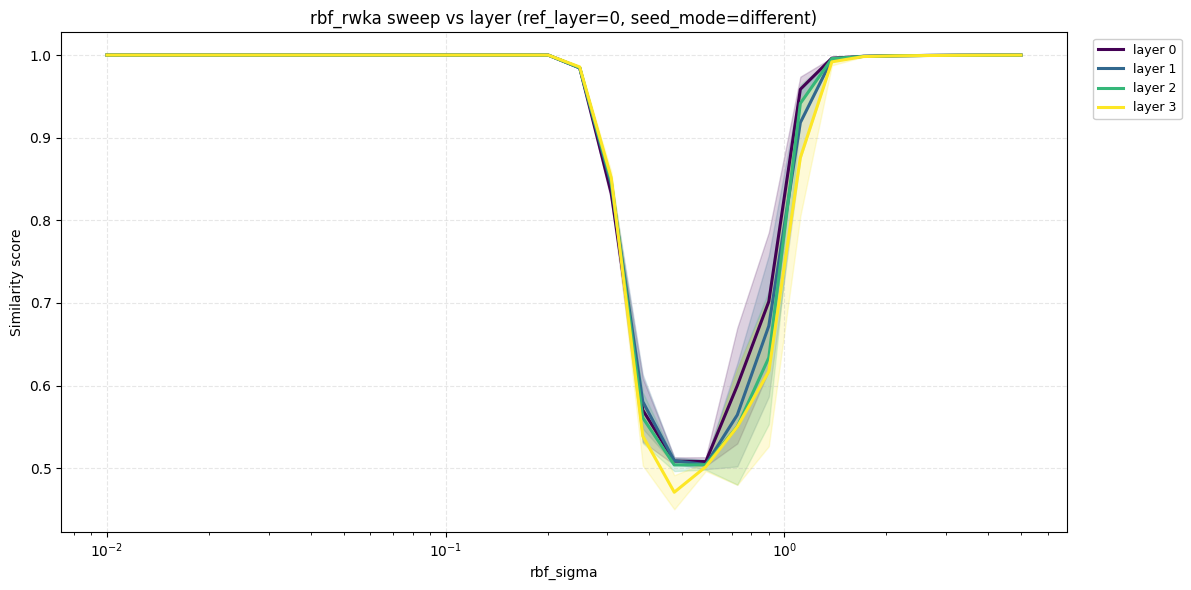

In [30]:
sweeps_dir = results_path / "sweeps"
if not sweeps_dir.exists():
    raise ValueError(f"No sweeps directory found at {sweeps_dir}")

available_metrics = list_sweep_metrics(sweeps_dir)
print(f"Sweep metrics found: {available_metrics}")

# Configure the reference layer and which metrics to plot
REF_LAYER = 0
METRICS_TO_PLOT = [m for m in ["softmax_rwka", "cka_rbf", "mutual_knn", "cknna", "rbf_rwka"] if m in available_metrics]
if not METRICS_TO_PLOT:
    METRICS_TO_PLOT = available_metrics

# Optional: restrict to a subset of other layers
LAYERS_TO_PLOT = [0, 1, 2, 3]  # e.g., [8, 9, 10, 11]

for metric_name in METRICS_TO_PLOT:
    entries = load_sweep_entries(metric_name, sweeps_dir)
    if not entries:
        print(f"No sweep entries found for {metric_name}")
        continue

    for seed_mode in ["same", "different"]:
        aggregated, param_name, _ = aggregate_layer_sweeps(
            entries,
            ref_layer=REF_LAYER,
            seed_mode=seed_mode,
            layers_to_plot=LAYERS_TO_PLOT,
        )

        save_path = figures_path / f"layer_sweep_{metric_name}_ref{REF_LAYER}_{seed_mode}.png"
        plot_layer_sweep_curves(
            aggregated,
            metric_name=metric_name,
            seed_mode=seed_mode,
            ref_layer=REF_LAYER,
            param_name=param_name,
            save_path=save_path,
        )